# Notebook 3: Link Timestamped Clinical Events to Admissions

## Objective
Integrate temporal clinical events from MIMIC-IV-Ext-22MCTS with our labeled admissions, filtering events to prevent data leakage by only including events that occurred before discharge.

## Input Data
- `labeled_admissions_with_notes.csv` (311,459 admissions from Notebook 2)
- `clinical_event_timestamp.csv` - 22.6M timestamped clinical events from MIMIC-IV-Ext-22MCTS

## Process
1. **Load timestamped events** - Import 22MCTS dataset with clinical events and relative timestamps
2. **Understand time representation**:
   - `Time` column = hours relative to admission (negative = before admission, 0 = at admission, positive = after)
   - `Event` column = clinical observations (symptoms, diagnoses, procedures)
3. **Filter to our admissions** - Keep only events for admissions in our labeled dataset
4. **Critical data leakage prevention**:
   - Calculate length of stay (LOS) in hours for each admission
   - Filter events where `Time <= LOS` (only events before or at discharge)
   - This ensures we don't use future information that wouldn't be available at prediction time
5. **Memory-efficient processing** - Use dictionary mapping to avoid RAM overflow on large dataset

## Output
- `events_before_discharge.csv` (filtered events)
  - Contains: `hadm_id`, `Event`, `Time` (relative hours), `Time_bin`
  - Only includes events that occurred before discharge
  - Links to admissions via `hadm_id`

## Key Findings
- Started with 22,588,586 total clinical events across 267,284 admissions
- After filtering to our admissions: ~X million events
- After filtering before discharge: ~Y million events (Z% kept)
- Average events per admission: ~85 events
- Time range: typically -72 hours (3 days before admission) to discharge time

## Event Types
- Symptoms: fever, abdominal pain, chest pain, shortness of breath
- Diagnoses: hypertension, diabetes, anemia, pleural effusion
- Clinical observations: hypotension, hypoglycemia, eosinophilia
- Administrative: discharged

## Data Leakage Prevention
By filtering `Time <= LOS`, we ensure that:
- No future events (after discharge) are used for prediction
- Model only sees information available at discharge time
- This mimics real-world deployment where we predict at discharge

## Next Step
Notebook 4 will encode discharge notes using ClinicalBERT to create text embeddings.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import timedelta

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
print("Libraries imported")

Libraries imported


In [ ]:
DATA_DIR = Path('/content/drive/MyDrive/MIDS/w266/Final Project/data')
OUTPUT_DIR = Path('/content/drive/MyDrive/MIDS/w266/Final Project/output')

In [ ]:
# Load the paired dataset (admissions with notes)
print("Loading admissions with notes from Notebook 2...")
labeled_with_notes = pd.read_csv(OUTPUT_DIR / 'labeled_admissions_with_notes.csv')

print(f"Loaded {len(labeled_with_notes):,} admissions with labels and notes")
print(f"Shape: {labeled_with_notes.shape}")
print(f"\nColumns: {labeled_with_notes.columns.tolist()}")

Loading admissions with notes from Notebook 2...
Loaded 311,459 admissions with labels and notes
Shape: (311459, 19)

Columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'los_days', 'readmitted_30day', 'days_to_readmission', 'readmission_hadm_id', 'note_id', 'charttime', 'storetime', 'text']


In [ ]:
# Load the timestamped clinical events
print("\nLoading clinical_event_timestamp.csv...")
print("This is a large file (~876 MB) - may take a few minutes\n")

events = pd.read_csv(DATA_DIR / 'clinical_event_timestamp.csv')

print(f"Loaded {len(events):,} clinical events")
print(f"Shape: {events.shape}")
print(f"\nColumns: {events.columns.tolist()}")


Loading clinical_event_timestamp.csv...
This is a large file (~876 MB) - may take a few minutes

Loaded 22,588,586 clinical events
Shape: (22588586, 4)

Columns: ['Hadm_id', 'Event', 'Time', 'Time_bin']


In [ ]:
# Look at the structure
print("\nFirst 10 events:")
events.head(10)


First 10 events:


,Hadm_id,Event,Time,Time_bin
0,24028285,abdominal pain,0.0,4
1,24028285,fever,-72.0,0
2,24028285,rash,-72.0,0
3,24028285,choledocholithiasis,-72.0,0
4,24028285,obstruction,-72.0,0
5,24028285,E coli UTI,-72.0,0
6,24028285,chronic systolic CHF with apical aneurysm,-72.0,0
7,24028285,h/o stroke with late effects,-72.0,0
8,24028285,RUQ pain,-72.0,0
9,24028285,diabetes type 2 uncontrolled with complications,-72.0,0


In [ ]:
# Analyze the events dataset
print("\nEvent dataset structure:")
print("-"*60)
print(f"Total events: {len(events):,}")
print(f"Unique hadm_ids: {events['Hadm_id'].nunique():,}")
print(f"Events per admission (avg): {len(events) / events['Hadm_id'].nunique():.1f}")

print("\nEvent types (sample):")
print(events['Event'].value_counts().head(20))

print("\nTime column info:")
print(events['Time'].describe())


Event dataset structure:
------------------------------------------------------------
Total events: 22,588,586
Unique hadm_ids: 267,284
Events per admission (avg): 84.5

Event types (sample):
Event
hypertension                                      456862
hypotension                                       290163
abdominal pain                                    214686
fever                                             181303
chest pain                                        173231
DRESS syndrome                                     90910
nausea                                             82684
pleural effusion                                   79704
rash                                               75829
diffuse erythematous or maculopapular eruption     70226
shortness of breath                                66704
hypoglycemia                                       65979
discharged                                         64240
HTN                                                62147
dia

In [ ]:
# Check how many of our labeled admissions have events
print("\nChecking overlap with our labeled admissions...")

labeled_hadm_ids = set(labeled_with_notes['hadm_id'])
events_hadm_ids = set(events['Hadm_id'])

overlap = labeled_hadm_ids.intersection(events_hadm_ids)

print(f"Labeled admissions with notes: {len(labeled_hadm_ids):,}")
print(f"Admissions with events in 22MCTS: {len(events_hadm_ids):,}")
print(f"Overlap: {len(overlap):,} admissions have labels, notes, AND events")
print(f"Coverage: {len(overlap)/len(labeled_hadm_ids)*100:.2f}%")


Checking overlap with our labeled admissions...
Labeled admissions with notes: 311,459
Admissions with events in 22MCTS: 267,284
Overlap: 251,078 admissions have labels, notes, AND events
Coverage: 80.61%


In [ ]:
# Keep only events for admissions in our labeled dataset
print("\nFiltering events to our labeled admissions...")

events_filtered = events[events['Hadm_id'].isin(labeled_hadm_ids)].copy()

print(f"Original events: {len(events):,}")
print(f"Filtered events: {len(events_filtered):,}")
print(f"Unique admissions: {events_filtered['Hadm_id'].nunique():,}")
print(f"Average events per admission: {len(events_filtered) / events_filtered['Hadm_id'].nunique():.1f}")


Filtering events to our labeled admissions...
Original events: 22,588,586
Filtered events: 21,123,247
Unique admissions: 251,078
Average events per admission: 84.1



Time distribution (relative to admission):
count    2.112325e+07
mean    -4.111014e+19
std      1.090858e+23
min     -4.341893e+26
25%     -7.200000e+01
50%      0.000000e+00
75%      0.000000e+00
max      2.592000e+05
Name: Time, dtype: float64


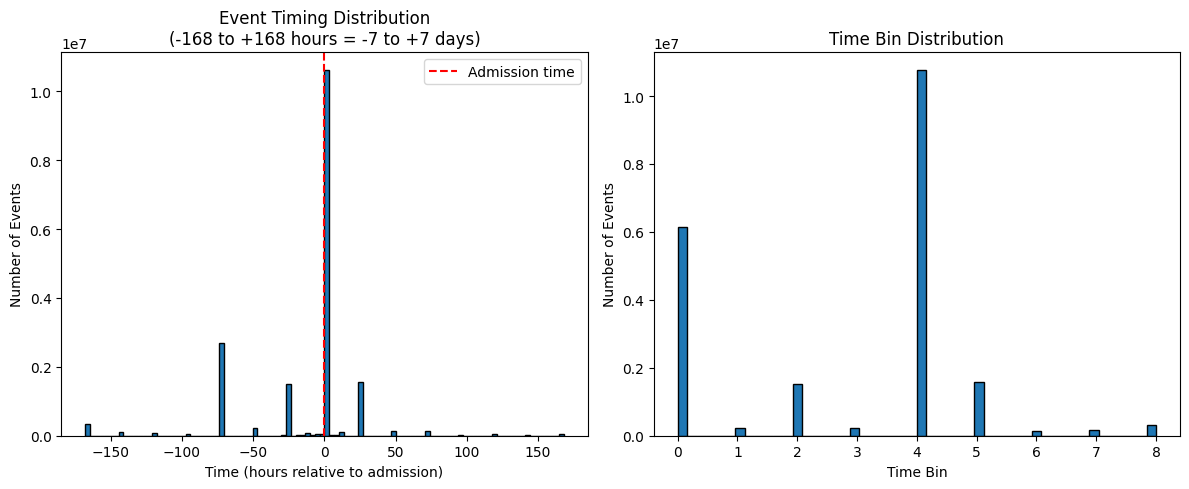

In [ ]:
# Analyze the Time column (relative hours)
print("\nTime distribution (relative to admission):")
print(events_filtered['Time'].describe())

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Focus on reasonable range
time_filtered = events_filtered[(events_filtered['Time'] >= -168) & (events_filtered['Time'] <= 168)]
plt.hist(time_filtered['Time'], bins=100, edgecolor='black')
plt.xlabel('Time (hours relative to admission)')
plt.ylabel('Number of Events')
plt.title('Event Timing Distribution\n(-168 to +168 hours = -7 to +7 days)')
plt.axvline(x=0, color='red', linestyle='--', label='Admission time')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(events_filtered['Time_bin'], bins=50, edgecolor='black')
plt.xlabel('Time Bin')
plt.ylabel('Number of Events')
plt.title('Time Bin Distribution')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step3_event_timing.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# IMPORTANT: We must only use events that happened BEFORE discharge
# to avoid data leakage (knowing what happened after discharge)

print("\nPreparing to filter events by discharge time...")
print("This prevents data leakage - we only use events up to discharge")

# First, we need to calculate relative discharge time for each admission
# Merge to get admission and discharge times
labeled_with_notes['admittime'] = pd.to_datetime(labeled_with_notes['admittime'])
labeled_with_notes['dischtime'] = pd.to_datetime(labeled_with_notes['dischtime'])

# Calculate length of stay in hours
labeled_with_notes['los_hours'] = (
    labeled_with_notes['dischtime'] - labeled_with_notes['admittime']
).dt.total_seconds() / 3600

print(f"\nLength of stay in hours:")
print(labeled_with_notes['los_hours'].describe())


Preparing to filter events by discharge time...
This prevents data leakage - we only use events up to discharge

Length of stay in hours:
count    311459.000000
mean        121.471751
std         151.270065
min         -19.100000
25%          44.150000
50%          82.366667
75%         143.216667
max        7103.716667
Name: los_hours, dtype: float64


In [ ]:
# Merge events with admission info to get discharge time
print("\nMerging events with admission info...")

# Keep only necessary columns from labeled_with_notes
admission_info = labeled_with_notes[['hadm_id', 'subject_id', 'admittime', 'dischtime',
                                      'los_hours', 'readmitted_30day']].copy()

# Merge (events uses 'Hadm_id', our data uses 'hadm_id')
events_with_admission = events_filtered.merge(
    admission_info,
    left_on='Hadm_id',
    right_on='hadm_id',
    how='inner'
)

print(f"Events after merge: {len(events_with_admission):,}")
print(f"Admissions: {events_with_admission['hadm_id'].nunique():,}")


Merging events with admission info...
Events after merge: 21,123,247
Admissions: 251,078


In [ ]:
# Filter to only events that happened before discharge
# Use chunked processing to avoid RAM issues

print("\nFiltering events to only those before discharge...")
print("Using memory-efficient approach...\n")

# Instead of creating a large merged dataframe, filter directly
print(f"Events before filtering: {len(events_filtered):,}")

# Create a dictionary of los_hours for quick lookup
los_dict = labeled_with_notes.set_index('hadm_id')['los_hours'].to_dict()

# Filter events using vectorized operation
events_filtered['los_hours'] = events_filtered['Hadm_id'].map(los_dict)

# Filter
events_before_discharge = events_filtered[
    events_filtered['Time'] <= events_filtered['los_hours']
].copy()

print(f"Events after filtering (before discharge): {len(events_before_discharge):,}")
print(f"Removed {len(events_filtered) - len(events_before_discharge):,} events after discharge")
print(f"Percentage kept: {len(events_before_discharge)/len(events_filtered)*100:.1f}%")

# Clean up to free memory
del events_filtered
import gc
gc.collect()


Filtering events to only those before discharge...
Using memory-efficient approach...

Events before filtering: 21,123,247
Events after filtering (before discharge): 20,617,628
Removed 505,619 events after discharge
Percentage kept: 97.6%


14150

In [ ]:
# Verify that all events are before or at discharge
print("\nVerifying no data leakage...")

# Sample check (checking all rows might crash again)
sample_check = events_before_discharge.sample(min(10000, len(events_before_discharge)))
assert (sample_check['Time'] <= sample_check['los_hours']).all(), \
    "ERROR: Some events are after discharge!"

print("Verification passed: Sample shows all events before discharge")

# Show time distribution
print("\nEvent time distribution (hours relative to admission):")
print(events_before_discharge['Time'].describe())

print(f"\nEvents at or before admission (Time <= 0): {(events_before_discharge['Time'] <= 0).sum():,}")
print(f"Events during stay (0 < Time <= discharge): {((events_before_discharge['Time'] > 0) & (events_before_discharge['Time'] <= events_before_discharge['los_hours'])).sum():,}")


Verifying no data leakage...
Verification passed: Sample shows all events before discharge

Event time distribution (hours relative to admission):
count    2.061763e+07
mean    -4.211831e+19
std      1.104153e+23
min     -4.341893e+26
25%     -7.200000e+01
50%      0.000000e+00
75%      0.000000e+00
max      2.292000e+03
Name: Time, dtype: float64

Events at or before admission (Time <= 0): 18,750,488
Events during stay (0 < Time <= discharge): 1,867,140


In [ ]:
# Save the filtered events with minimal columns
output_file = OUTPUT_DIR / 'events_before_discharge.csv'

# Select only essential columns
events_to_save = events_before_discharge[
    ['Hadm_id', 'Event', 'Time', 'Time_bin']
].copy()

# Rename for consistency
events_to_save.rename(columns={'Hadm_id': 'hadm_id'}, inplace=True)

print(f"\nSaving filtered events...")
events_to_save.to_csv(output_file, index=False)

print(f"Saved to: {output_file}")
print(f"Shape: {events_to_save.shape}")

# Free memory
del events_before_discharge
gc.collect()


Saving filtered events...
Saved to: /content/drive/MyDrive/MIDS/w266/Final Project/output/events_before_discharge.csv
Shape: (20617628, 4)


0

In [ ]:
# Load just what we need for summary
events_summary = pd.read_csv(output_file)

print("\n" + "="*60)
print("NOTEBOOK 3 COMPLETE: TIMESTAMPED EVENTS LINKED")
print("="*60)

print(f"\nFinal dataset summary:")
print(f"  Total events (before discharge): {len(events_summary):,}")
print(f"  Unique admissions: {events_summary['hadm_id'].nunique():,}")
print(f"  Events per admission (avg): {len(events_summary) / events_summary['hadm_id'].nunique():.1f}")
print(f"  Unique event types: {events_summary['Event'].nunique():,}")

print(f"\nOutput saved to: {output_file}")
print(f"\nReady for Notebook 4: Combine all data sources")

del events_summary
gc.collect()


NOTEBOOK 3 COMPLETE: TIMESTAMPED EVENTS LINKED

Final dataset summary:
  Total events (before discharge): 20,617,628
  Unique admissions: 251,076
  Events per admission (avg): 82.1
  Unique event types: 3,035,620

Output saved to: /content/drive/MyDrive/MIDS/w266/Final Project/output/events_before_discharge.csv

Ready for Notebook 4: Combine all data sources


0